<a href="https://colab.research.google.com/github/freitas-econophys/Fisica_com_python1/blob/main/ridge_plot_Cv_liquidos/ridge_plot_Cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Tarefa 1
# Disciplina: Física com Python 1 (2026.2) - CBPF
# Autor: Isaque Porto de Freitas
# Observação: Código desenvolvido para fins de avaliação acadêmica.
#             Disponibilizado publicamente sob a Licença MIT para
#             consulta educacional.

# Aplicação do ridgeline plot à capacidade térmica isocórica de líquidos simples

# Verificar se o gráfico C_v(T) irá rodar corretamente para um valor específico
# da intensidade da desordem (\sigma)

Calculando a tabela numérica...


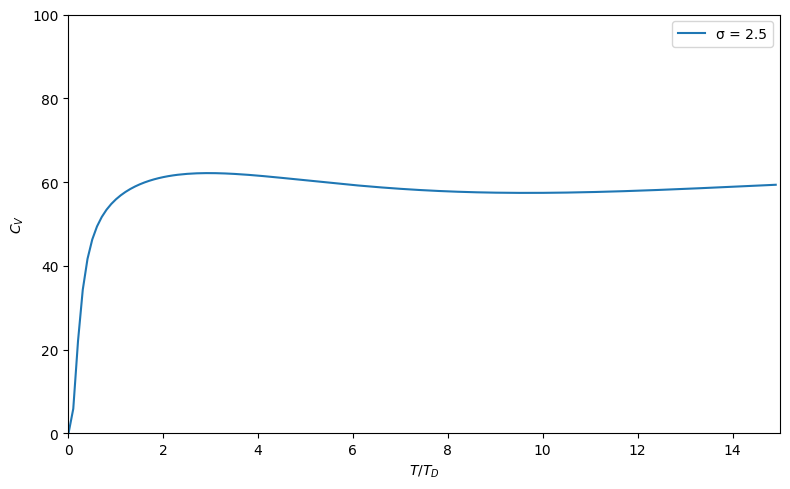

Gráfico da primeira etapa: 'grafico_cv.png'.


In [18]:
###############################################################################################

# Etapa 1) Cálculo do excess C_v para um valor fixo da intensidade da desordem

import mpmath as mp
import matplotlib.pyplot as plt

# 1. CONFIGURAÇÃO DE PRECISÃO PARA O SOMATÓRIO DA SÉRIE DA DZT
mp.mp.dps = 30

# 2. DEFINIÇÃO DOS PARÂMETROS

TMC = 1/100       # Termo de regularização infravermelha (corresponde ao limite inferior das integrações)
SIGMA_A = 2.5     # Strength da desordem
b = 1             # Valor do parâmetro da série

# Definição da função f_k(t) e integração numérica em y

def zetak(t, tmc, s, k):
    integrand = lambda y: y * mp.sqrt(y**2 + k * s**2) * mp.log(2 * mp.sinh(y / (2 * t)))
    return -mp.quad(integrand, [tmc, 1])

def dzetak(t, tmc, s, k):
    integrand = lambda y: y**2 * mp.sqrt(y**2 + k * s**2) * mp.coth(y / (2 * t))
    return -(1/2) * mp.quad(integrand, [tmc, 1])

def ddzetak(t, tmc, s, k):
    integrand = lambda y: y**3 * mp.sqrt(y**2 + k * s**2) * (1 / mp.sinh(y / (2 * t)))**2
    return (1/4) * mp.quad(integrand, [tmc, 1])

def zeta(t, tmc):
    integrand = lambda y: y**2 * mp.log(2 * mp.sinh(y / (2 * t)))
    return -mp.quad(integrand, [tmc, 1])

def dzeta(t, tmc):
    integrand = lambda y: y**3 * mp.coth(y / (2 * t))
    return -(1/2) * mp.quad(integrand, [tmc, 1])

def ddzeta(t, tmc):
    integrand = lambda y: y**4 * (1 / mp.sinh(y / (2 * t)))**2
    return (1/4) * mp.quad(integrand, [tmc, 1])


# --- Calor específico e somatório ---

def Cv1(t, tmc, s, b, k):
    # Prefator do somatório: (-1)^(k+1) * b^k / (k * k!)
    prefactor = ((-1)**(k+1) * (b**k)) / (k * mp.factorial(k))

    # Termo exponencial
    exponent = (k - 1) * zeta(t, tmc) + zetak(t, tmc, s, k)
    term_exp = mp.exp(exponent)

    # Termos vindos das derivadas
    bracket1 = (k - 1) * dzeta(t, tmc) + dzetak(t, tmc, s, k)
    bracket2 = (k - 1) * ddzeta(t, tmc) + ddzetak(t, tmc, s, k)

    return (3 /(t**2)) * ddzeta(t, tmc) + prefactor * term_exp * (3 / (t**2)) * (bracket1**2 + bracket2)
            #O fator de 3 multiplicando cada termo é por conta de cada zeta set associada a
            #um grau de liberdade, sendo 2 transversais e dois longitudinais.

def Cv1TabSum(tmc, s, b):
    table_data = []
    t = mp.mpf(tmc)
    while t <= 15:
        total_sum = mp.mpf(0)
        for k in range(1, 51):
            total_sum += Cv1(t, tmc, s, b, k)
        table_data.append([float(t), float(total_sum)])
        t += mp.mpf('0.1')
    return table_data


# --- GERANDO A TABELA PARA UM ÚNICO VALOR DO STRENGTH DA DESORDEM ---

print("Calculando a tabela numérica...")
Tab1 = Cv1TabSum(TMC, SIGMA_A, b)

T = [row[0] for row in Tab1]
Cv = [row[1] for row in Tab1]


# --- PLOTANDO O GRÁFICO ---
plt.figure(figsize=(8, 5))
plt.plot(T, Cv, label=f'σ = {SIGMA_A}')

plt.xlabel(r'$T/T_D$')
plt.ylabel(r'$C_V$')
plt.xlim(0, 15)
plt.ylim(0, 100)

plt.legend()
plt.tight_layout()
plt.savefig('grafico_cv.png', dpi=300)
plt.show()

print("Gráfico da primeira etapa: 'grafico_cv.png'.")

In [19]:
# Etapa 2) Guardando o resultado dentro de um dicionário

tabelas = {}

sigmas = [2.5, 3.0, 3.5, 4.0]

for sigma in sigmas:
    print(f"Calculando sigma = {sigma}...")
    tabelas[sigma] =  Cv1TabSum(TMC, sigma, b)
    print(f"Sigma = {sigma} concluído.")

Calculando sigma = 2.5...
Sigma = 2.5 concluído.
Calculando sigma = 3.0...
Sigma = 3.0 concluído.
Calculando sigma = 3.5...
Sigma = 3.5 concluído.
Calculando sigma = 4.0...
Sigma = 4.0 concluído.


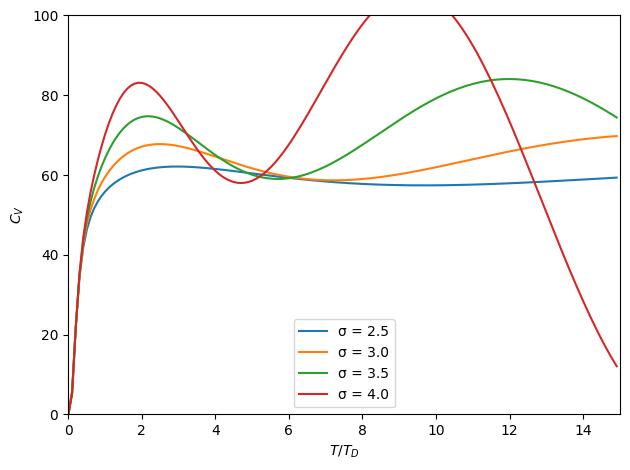

In [20]:
#################################################################################################

# Etapa 3) Cálculo com diferentes valores do strengths da desordem

# Organizando cada resultado de sigma extraindo T e Cv de cada tabela

dados = {}

for sigma in sigmas:
    T = [row[0] for row in tabelas[sigma]]
    Cv = [row[1] for row in tabelas[sigma]]
    dados[sigma] =  (T,  Cv) # Moved this line inside the loop



# Visualizando se os dados estão corretos (quatro curvas juntas, sem deslocament0):

for sigma in sigmas:
    T, Cv = dados[sigma]
    plt.plot(T, Cv, label=f'σ = {sigma}')

plt.xlabel(r'$T/T_D$')
plt.ylabel(r'$C_V$')
plt.xlim(0, 15)
plt.ylim(0, 100)

plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Etapa 4) Criando o DataFrame

import pandas as pd

T_dados = []
Cv_dados = []
sigma_dados = []

for sigma in sigmas:
    T, Cv = dados[sigma]

    for t, cv in zip(T, Cv):
        T_dados.append(t)
        Cv_dados.append(cv)
        sigma_dados.append(sigma)

df = pd.DataFrame({
    'T': T_dados,
    'Cv': Cv_dados,
    'sigma': sigma_dados
})

df.head()

,T,Cv,sigma
0,0.01,0.003849,2.5
1,0.11,5.865560,2.5
2,0.21,22.044070,2.5
3,0.31,34.281005,2.5
4,0.41,41.662222,2.5


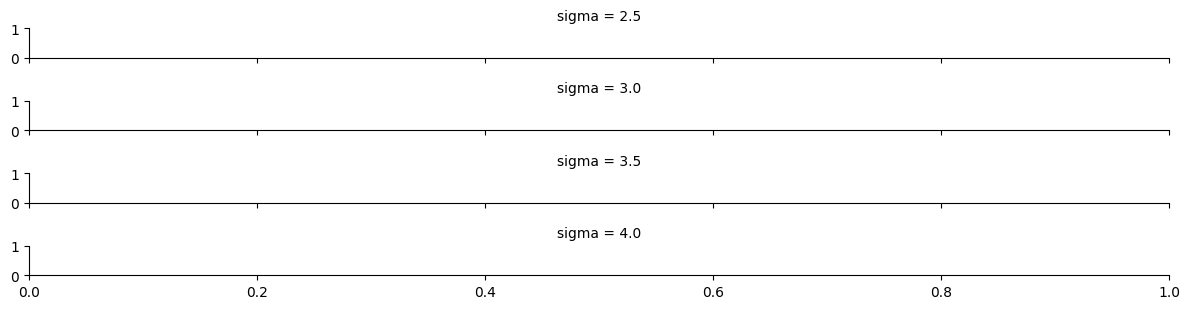

In [55]:
# Etapa 5) Criando o FacetGrid

import seaborn as sns
import numpy as np


g = sns.FacetGrid(
    df, # dataframe da célula anterios
    row="sigma",
    hue="sigma",
    aspect=15, # escolhi comprimir o eixo horizontal de cadaa faixa
    height=0.8 #controla altura de cada faixa
    )

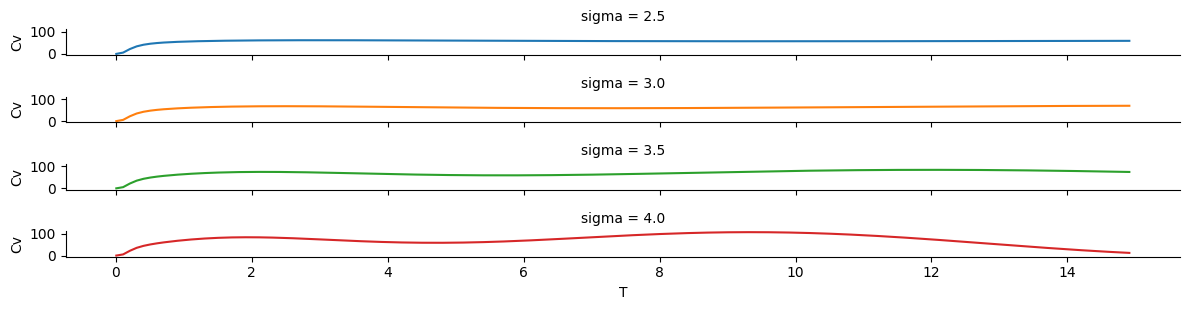

In [56]:
# Etapa 5) Incluindo as curvas (Cv X T) no grid

# Fazer T --> eixo horizontal
# Fazer Cv --> eixo vertical

g.map(plt.plot, "T", "Cv")
plt.show()


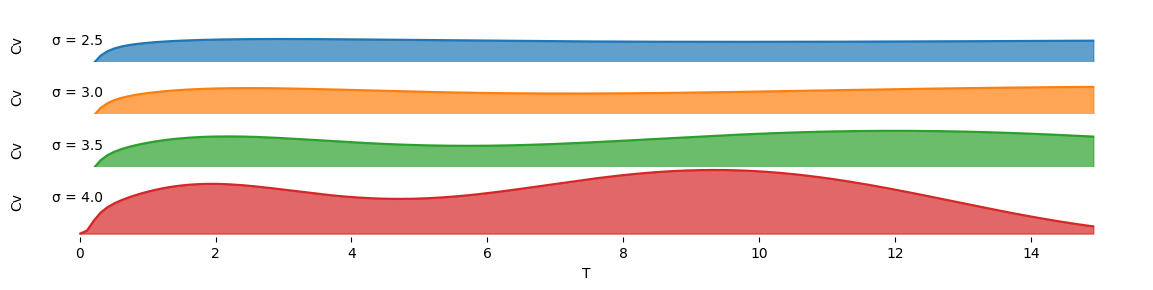

In [60]:
# Etapa 6 ) Ajuste visual das curvas

g = sns.FacetGrid(
    df,
    row="sigma",
    hue="sigma",
    aspect=15,
    height=0.8
)

# Curvas de capacidade térmica
g.map(plt.plot, "T", "Cv")

# Preenchimento das curvas com as cores
def fill(x, y, **kwargs):
    plt.fill_between(x, y, 0, alpha=0.7, color=kwargs["color"])

g.map(fill, "T", "Cv")

# Ajustes visuais
g.figure.subplots_adjust(hspace=-0.25)
g.set_titles("")
g.set(yticks=[])
g.despine(bottom=True, left=True)

# Indicando os valores de sigma
for ax, sigma in zip(g.axes.flat, sigmas):
    ax.text(0.02, 0.5, f'σ = {sigma}', transform=ax.transAxes)

plt.show()